**Grad-CAM:** Gradient-weighted Class Activation Mapping (Grad-CAM) is a visualization technique that highlights regions in an input image contributing most to a model's prediction. It uses gradients from the final convolutional layer to generate heatmaps, providing interpretability by showing which areas influenced the decision, making deep learning models more transparent and explainable.

**Steps associated with Grad-CAM:**

**Forward pass:** The image is passed through the model, and we compute the class score for a target class.

**Backward pass:** The gradient with respect to the class score is computed and backpropagated.

**Activation and Gradient Handling:** We pool the gradients across all channels of the last convolutional layer. These pooled gradients are used to weight the activations, producing a heatmap that highlights important areas in the image.

**Normalization:** The heatmap is normalized to the range [0, 1] and resized to match the input image dimensions.

**Importance of Grad-CAM heatmap:** The Grad-CAM heatmap is applied to the image to visualize important regions for the target class prediction. A color overlay is used to enhance the visibility of the regions of interest. The output will be a visualization of the image with the Grad-CAM heatmap superimposed on top of it. The regions of the image that contribute most to the model's prediction will be highlighted in warmer colors (e.g., red and yellow).

**Install and import dependencies**

In [1]:
# Install OpenCV (usually pre-installed on Colab, but ensures headless version is present)
!pip install opencv-python-headless -q

# Core PyTorch library for tensors, autograd, and neural network execution
import torch

# Neural network building blocks (used indirectly via torchvision's model)
import torch.nn as nn

# Pretrained model definitions (ResNet18) and the modern weights enum API
import torchvision.models as models
from torchvision.models import ResNet18_Weights   # Explicit weights class, replaces deprecated pretrained=True

# Image preprocessing transforms (resize, tensor conversion, normalization)
import torchvision.transforms as transforms

# For numerical array operations on the heatmap (ReLU, normalization)
import numpy as np

# For displaying the original image and the Grad-CAM overlay side by side
import matplotlib.pyplot as plt

# For resizing the heatmap and applying a color map for visualization
import cv2

# For downloading a real sample image directly into the Colab runtime
import urllib.request

# For opening the downloaded image file as a PIL Image (required by torchvision transforms)
from PIL import Image

**Load the pretrained model with the current (non-deprecated) API**

In [2]:
# Load ResNet18 using the current weights= API (pretrained=True is deprecated since torchvision 0.13)
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)   # DEFAULT pulls the best available ImageNet weights
# Set the model to evaluation mode: disables dropout and freezes BatchNorm running statistics.
# This does NOT disable gradient tracking -- we still need gradients for Grad-CAM.
model.eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**Register forward and backward hooks on the target layer**

In [3]:
# Placeholder variables that the hooks below will fill in during the forward/backward pass.
# 'global' is required inside the hook functions so they modify these outer variables, not local copies.
activations = None   # Will store the target layer's output feature maps (forward pass)
gradients = None      # Will store the gradient of the class score w.r.t. that layer's output (backward pass)

# Forward hook: fires every time the target layer completes a forward pass.
# module = the layer itself, input = its input tensor(s), output = its output tensor.
def forward_hook(module, input, output):
    global activations
    activations = output   # Save the feature maps so we can weight them later

# Backward hook: fires every time gradients are computed for the target layer during .backward().
# grad_input = gradients w.r.t. the layer's inputs, grad_output = gradients w.r.t. the layer's outputs.
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]   # grad_output is a tuple; index 0 is the gradient tensor we need

# Select the final convolutional layer of ResNet18 as the Grad-CAM target.
# layer4[1] = the second (last) BasicBlock in the last residual stage; conv2 = its second conv layer.
target_layer = model.layer4[1].conv2

# Attach the forward hook to capture activations during inference.
target_layer.register_forward_hook(forward_hook)
# Attach the FULL backward hook (register_backward_hook is deprecated and has known
# grad_input/grad_output ordering bugs on multi-input modules -- full_backward_hook fixes this).
target_layer.register_full_backward_hook(backward_hook)

**Define the image preprocessing pipeline**

In [4]:
# Standard ImageNet preprocessing pipeline, matching how ResNet18 was originally trained.
transform = transforms.Compose([
    transforms.Resize((224, 224)),    # Resize to ResNet's expected 224x224 input size
    transforms.ToTensor(),            # Convert PIL image (H,W,C, 0-255) to a PyTorch tensor (C,H,W, 0-1)
    transforms.Normalize(             # Normalize using ImageNet's per-channel mean/std statistics
        mean=[0.485, 0.456, 0.406],   # Computed once over the full ImageNet training set
        std=[0.229, 0.224, 0.225]
    )
])

**Load a native-resolution sample image (replaces the upscaled CIFAR-10 image)**

In [5]:
# Download a real, native-resolution sample image instead of upscaling a 32x32 CIFAR-10 image.
# CIFAR-10 images stretched to 224x224 become heavily blurred, which produces a degraded,
# hard-to-interpret Grad-CAM heatmap. This is a standard example image used in PyTorch's own docs.
image_url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
image_path = "sample.jpg"
urllib.request.urlretrieve(image_url, image_path)   # Download the image to the local Colab filesystem

# Open the downloaded file as a PIL Image in RGB mode (required input type for torchvision transforms)
pil_image = Image.open(image_path).convert("RGB")

# Apply the preprocessing pipeline defined in Cell 4
input_tensor = transform(pil_image)          # Shape: (3, 224, 224)
input_tensor = input_tensor.unsqueeze(0)      # Add a batch dimension -> (1, 3, 224, 224), as the model expects a batch

**Forward pass and backward pass to populate activations/gradients**

In [6]:
# Forward pass: run the image through ResNet18 to get class scores (logits) for all 1000 ImageNet classes.
output = model(input_tensor)
# Identify the class with the highest score -- this is the model's predicted class index.
predicted_class = output.argmax(dim=1).item()
print(f"Predicted ImageNet class index: {predicted_class}")   # For reference; map to a label list if needed

# Zero out any gradients left over from previous computations (there shouldn't be any here, but this is best practice).
model.zero_grad()
# Extract the scalar score corresponding to the predicted class.
class_score = output[0, predicted_class]
# Backpropagate from that single scalar score. This triggers backward_hook on the target layer,
# populating the 'gradients' variable with d(class_score)/d(target_layer output).
class_score.backward()

Predicted ImageNet class index: 258


**Compute the Grad-CAM heatmap**

In [7]:
# Average the gradients over the batch, height, and width dimensions, leaving one weight per channel.
# This is the Grad-CAM "alpha_k" term: how important each feature-map channel is to the predicted class.
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

# Clone the activations before modifying them, rather than editing in place. This avoids the class of
# RuntimeError that in-place edits on autograd-tracked tensors can trigger, and keeps the original
# 'activations' tensor untouched in case it's needed again.
weighted_activations = activations.clone()

# Multiply every channel of the feature map by its corresponding importance weight.
for i in range(weighted_activations.shape[1]):   # shape[1] = number of channels in this layer's output
    weighted_activations[:, i, :, :] *= pooled_gradients[i]

# Average across all weighted channels to collapse them into a single 2D heatmap.
heatmap = torch.mean(weighted_activations, dim=1).squeeze()   # Shape: (H, W)
# Apply ReLU (via np.maximum) to keep only features that positively influence the predicted class.
heatmap = np.maximum(heatmap.detach().numpy(), 0)   # .detach() removes it from the autograd graph before converting to NumPy
# Normalize the heatmap to the [0, 1] range for visualization; guard against dividing by zero.
heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1

**Prepare the original image and overlay the heatmap**

In [8]:
# Convert the input tensor back into a displayable image: (C,H,W) -> (H,W,C), then to a NumPy array.
original_image = input_tensor.squeeze(0).permute(1, 2, 0).numpy()
# Reverse the normalization applied in Cell 4 (multiply by std, add back mean) to restore real pixel values.
original_image = (original_image * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
# Clip to a valid [0, 1] pixel range (normalization reversal can slightly overshoot).
original_image = np.clip(original_image, 0, 1)

# Resize the heatmap (currently the target layer's small spatial resolution) up to the full 224x224 image size.
heatmap_resized = cv2.resize(heatmap, (224, 224))
# Convert the normalized [0,1] heatmap to [0,255] uint8, then apply a JET color map for a red/blue visualization.
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
# Normalize the color-mapped heatmap back to [0, 1] so it can be blended with the original image.
heatmap_colored = np.float32(heatmap_colored) / 255

# Blend the heatmap and the original image: 40% heatmap opacity over 60% original image brightness.
overlayed_image = 0.4 * heatmap_colored + 0.6 * original_image

**Display the result**

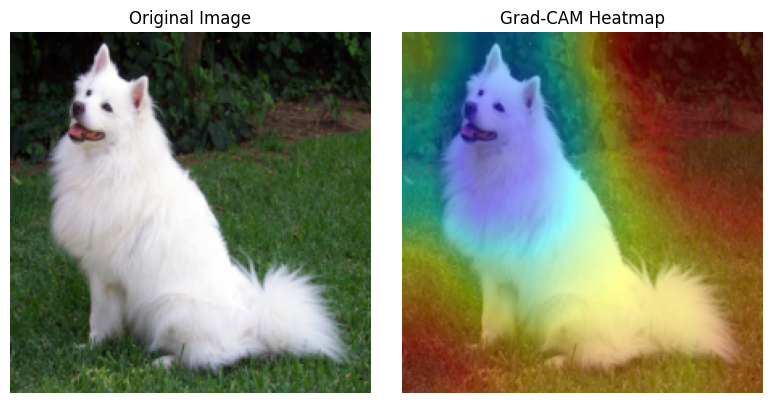

In [9]:
# Create a figure with two side-by-side panels
plt.figure(figsize=(8, 4))

# Left panel: the original (unmodified) input image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_image)
plt.axis('off')   # Hide axis ticks/labels for a cleaner image display

# Right panel: the Grad-CAM heatmap overlaid on the original image
plt.subplot(1, 2, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(overlayed_image)
plt.axis('off')

plt.tight_layout()   # Adjust spacing so titles/images don't overlap
plt.show()            # Render the figure in the Colab output cell

## **Output Interpretation**

- **The picture on the left** is just the original photo — a fluffy white dog sitting on grass, nothing altered.

- **The picture on the right** shows where the AI "looked" when it decided what breed of dog this was. Think of it like a heat map on a weather forecast — but instead of showing temperature, it shows *where the computer paid the most attention*.

- **Red and orange areas mean "the AI focused here a lot."** **Blue and purple areas mean "the AI mostly ignored this part."**

- **The surprising part:** the dog's face — which is usually the first thing a person looks at to recognize a dog — is colored blue in this image. That means the AI barely used the face to make its decision.

- **Instead, the AI paid most attention to two things:** the dog's fluffy tail, and, oddly, the grass and bushes in the background behind the dog.

- **In simple terms:** the AI seems to have identified the dog mainly by its fuzzy, cloud-like fur texture and the surroundings it was sitting in — not by looking at its face the way a person naturally would.

- **Why this matters:** it's a bit like a person recognizing their friend only by their jacket and the street they're standing on, rather than by their face. It might work most of the time, but it's not the most reliable way to do it — if you put the same dog in a different location, or against a different background, the AI might get confused, even though any person would still easily recognize the same dog.

- **The takeaway:** this tool doesn't just tell us the AI's final answer — it also shows us *how* the AI got there, which helps us catch cases where the AI might be making a correct guess for the wrong reasons.

## **Why Doesn't the AI Look at the Dog's Face?**

**Question:** Why does Grad-CAM show that the AI barely used the dog's face to make its decision?

- **The AI never learned "look at the face" as a rule.** Unlike a person, nobody ever taught it that faces matter most — it only learned by looking at millions of photos and figuring out patterns on its own.

- **It just kept whatever worked, even if it seems odd to us.** During training, the AI's only goal was to get the right answer. If fur texture, tail shape, or even the grassy background helped it guess correctly, it held onto those clues — it had no reason to prefer the face over anything else.

- **For fluffy dogs, fur can be a stronger clue than the face.** Some breeds look very similar in the face but have distinct coat textures or body shapes. So the AI may have leaned on the fluffy tail because it's actually a reliable "fingerprint" for that breed.

- **Backgrounds can accidentally become part of the "recipe."** If many training photos of this breed happened to be taken outdoors on grass, the AI may have picked up "grass nearby" as a helpful hint — not because grass is logically related to the dog, but because it kept showing up together with the right answer.

- **In short: the AI takes shortcuts, not principles.** It doesn't reason the way people do. It just finds whatever visual patterns help it get the right answer most often, even if those patterns would seem strange or unreliable to a human.

- **Why this matters:** This is exactly why tools like Grad-CAM are useful. Without it, we would only see the AI's final guess and assume it looked at the dog "properly." The heatmap reveals that the AI might be right for a shaky reason — if the same dog were photographed on a wooden floor instead of grass, the AI could become far less confident, even though the dog itself hasn't changed at all.